# Exploratory Data Analysis (EDA)
## E-commerce Database (PostgreSQL)

This notebook performs a **comprehensive, automated EDA** across the entire e-commerce database schema:

- `customers`
- `orders`
- `order_items`
- `order_payments`
- `order_reviews`
- `products`
- `sellers`
- `product_category_name_translation`

**What this notebook does automatically:**
1. Connects to PostgreSQL and loads every table into a Pandas DataFrame.
2. Profiles each table individually (shape, dtypes, memory, nulls, duplicates, distributions, outliers, categorical/numerical/datetime/text analysis).
3. Analyzes relationships between tables via foreign keys (join completeness, orphan records, cardinality).
4. Runs data-quality checks (invalid values, impossible dates, blank strings).
5. Produces visualizations and auto-generated business insights for every table.
6. Summarizes overall findings and recommendations at the end.

> **Note:** Only the database connection cell (credentials) needs editing. Everything else runs top-to-bottom automatically and adapts to whichever columns/types are actually present.


## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import missingno as msno
from sqlalchemy import create_engine, text

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Database Connection

**Edit only this cell** with your PostgreSQL credentials before running the notebook.


In [2]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

connection_string = (
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

try:
    engine = create_engine(connection_string)
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("✅ Successfully connected to Supabase PostgreSQL.")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Successfully connected to Supabase PostgreSQL.


## 3. Load Data into DataFrames

In [3]:
TABLES = [
    "customers",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "products",
    "sellers",
    "product_category_name_translation",
]

dataframes = {}

def load_table(table_name, engine):
    """Load a table into a DataFrame, handling errors gracefully."""
    try:
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql(query, engine)
        print(f"✅ Loaded '{table_name}': {df.shape[0]:,} rows x {df.shape[1]} columns")
        return df
    except Exception as e:
        print(f"❌ Failed to load '{table_name}': {e}")
        return None

for t in TABLES:
    dataframes[t] = load_table(t, engine)

customers = dataframes.get("customers")
orders = dataframes.get("orders")
order_items = dataframes.get("order_items")
order_payments = dataframes.get("order_payments")
order_reviews = dataframes.get("order_reviews")
products = dataframes.get("products")
sellers = dataframes.get("sellers")
product_category_name_translation = dataframes.get("product_category_name_translation")


✅ Loaded 'customers': 99,441 rows x 5 columns
✅ Loaded 'orders': 99,441 rows x 8 columns
✅ Loaded 'order_items': 112,650 rows x 7 columns
✅ Loaded 'order_payments': 103,886 rows x 5 columns
✅ Loaded 'order_reviews': 2,872 rows x 7 columns
✅ Loaded 'products': 32,951 rows x 9 columns
✅ Loaded 'sellers': 3,095 rows x 4 columns
✅ Loaded 'product_category_name_translation': 71 rows x 2 columns


## 4. Database & Schema Overview

Known relationships (inferred from foreign keys / shared column names):

| Child Table | Foreign Key | Parent Table | Parent Key |
|---|---|---|---|
| orders | customer_id | customers | customer_id |
| order_items | order_id | orders | order_id |
| order_items | product_id | products | product_id |
| order_items | seller_id | sellers | seller_id |
| order_payments | order_id | orders | order_id |
| order_reviews | order_id | orders | order_id |
| products | product_category_name | product_category_name_translation | product_category_name |


In [4]:
RELATIONSHIPS = [
    {"child": "orders", "fk": "customer_id", "parent": "customers", "pk": "customer_id"},
    {"child": "order_items", "fk": "order_id", "parent": "orders", "pk": "order_id"},
    {"child": "order_items", "fk": "product_id", "parent": "products", "pk": "product_id"},
    {"child": "order_items", "fk": "seller_id", "parent": "sellers", "pk": "seller_id"},
    {"child": "order_payments", "fk": "order_id", "parent": "orders", "pk": "order_id"},
    {"child": "order_reviews", "fk": "order_id", "parent": "orders", "pk": "order_id"},
    {"child": "products", "fk": "product_category_name", "parent": "product_category_name_translation", "pk": "product_category_name"},
]

PRIMARY_KEYS = {
    "customers": ["customer_id"],
    "orders": ["order_id"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "product_category_name_translation": ["product_category_name"],
}

summary_rows = []
for t, df in dataframes.items():
    if df is not None:
        summary_rows.append({
            "table": t,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "memory_MB": round(df.memory_usage(deep=True).sum() / 1e6, 2),
            "primary_key": ", ".join(PRIMARY_KEYS.get(t, []))
        })

schema_summary = pd.DataFrame(summary_rows)
schema_summary


,table,rows,columns,memory_MB,primary_key
0,customers,99441,5,27.88,customer_id
1,orders,99441,8,25.85,order_id
2,order_items,112650,7,30.98,"order_id, order_item_id"
3,order_payments,103886,5,17.02,"order_id, payment_sequential"
4,order_reviews,2872,7,0.85,review_id
5,products,32951,9,6.60,product_id
6,sellers,3095,4,0.62,seller_id
7,product_category_name_translation,71,2,0.01,product_category_name


## 5. Reusable EDA Helper Functions

These functions are called for every table to avoid repetitive code. Each automatically detects which analyses are applicable and skips the rest.


In [7]:
def infer_column_types(df):
    """Classify columns into numerical, categorical, datetime, boolean, and text."""
    col_types = {"numerical": [], "categorical": [], "datetime": [], "boolean": [], "text": []}
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_bool_dtype(s):
            col_types["boolean"].append(col)
        elif pd.api.types.is_datetime64_any_dtype(s):
            col_types["datetime"].append(col)
        elif pd.api.types.is_numeric_dtype(s):
            col_types["numerical"].append(col)
        elif "date" in col.lower() or "timestamp" in col.lower() or "_at" in col.lower():
            try:
                pd.to_datetime(s.dropna().head(50))
                col_types["datetime"].append(col)
            except Exception:
                col_types["text"].append(col)
        else:
            nunique = s.nunique(dropna=True)
            avg_len = s.dropna().astype(str).str.len().mean() if s.notna().any() else 0
            if nunique <= max(50, int(0.05 * len(s))) and (avg_len < 40 or avg_len != avg_len):
                col_types["categorical"].append(col)
            else:
                col_types["text"].append(col)
    return col_types


def coerce_datetimes(df, col_types):
    """Convert detected datetime-like columns to actual datetime dtype."""
    for col in col_types["datetime"]:
        if not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def table_overview(name, df):
    print(f"{'='*70}\nTABLE OVERVIEW: {name}\n{'='*70}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB\n")
    print("Column dtypes:")
    print(df.dtypes)
    print("\nSample records:")
    display(df.head(5))
    print("\nUnique value counts per column:")
    display(df.nunique().sort_values(ascending=False).to_frame("n_unique"))


def missing_value_analysis(name, df):
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    missing_df = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
    missing_df = missing_df[missing_df["null_count"] > 0].sort_values("null_pct", ascending=False)

    if missing_df.empty:
        print(f"✅ No missing values detected in '{name}'.")
        return

    display(missing_df)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(missing_df))))
    sns.barplot(x=missing_df["null_pct"], y=missing_df.index, ax=ax, color="indianred")
    ax.set_title(f"Missing Value % by Column — {name}")
    ax.set_xlabel("% Missing")
    plt.tight_layout()
    plt.show()

    try:
        msno.matrix(df[missing_df.index.tolist()], figsize=(10, 4))
        plt.title(f"Missing Value Matrix — {name}")
        plt.show()
    except Exception as e:
        print(f"(Skipped missingno matrix: {e})")


def duplicate_analysis(name, df, pk_cols):
    n_full_dupes = df.duplicated().sum()
    print(f"Fully duplicated rows: {n_full_dupes:,}")

    valid_pk = [c for c in pk_cols if c in df.columns]
    if valid_pk:
        n_pk_dupes = df.duplicated(subset=valid_pk).sum()
        print(f"Duplicate primary keys ({', '.join(valid_pk)}): {n_pk_dupes:,}")
    else:
        print("No primary key columns found to check.")


def categorical_analysis(name, df, cat_cols, max_cats_to_plot=8):
    if not cat_cols:
        print("No categorical columns detected.")
        return
    for col in cat_cols:
        vc = df[col].value_counts(dropna=False)
        print(f"\n--- {col} ({df[col].nunique()} unique values) ---")
        display(vc.head(10).to_frame("count"))

        if df[col].nunique() <= 50:
            top = vc.head(max_cats_to_plot)
            fig = px.bar(x=top.values, y=top.index.astype(str), orientation="h",
                         title=f"Top categories — {name}.{col}",
                         labels={"x": "Count", "y": col})
            fig.update_layout(height=400, yaxis={"categoryorder": "total ascending"})
            fig.show()


def numerical_analysis(name, df, num_cols):
    if not num_cols:
        print("No numerical columns detected.")
        return
    desc = df[num_cols].describe().T
    desc["skew"] = df[num_cols].skew()
    desc["kurtosis"] = df[num_cols].kurt()
    display(desc)


def distribution_analysis(name, df, num_cols):
    if not num_cols:
        return
    for col in num_cols:
        data = df[col].dropna()
        if data.empty or data.nunique() <= 1:
            continue
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(data, kde=True, ax=axes[0], color="steelblue")
        axes[0].set_title(f"Histogram + KDE — {name}.{col}")
        sns.boxplot(x=data, ax=axes[1], color="lightcoral")
        axes[1].set_title(f"Box Plot — {name}.{col}")
        plt.tight_layout()
        plt.show()


def outlier_analysis(name, df, num_cols):
    if not num_cols:
        return
    rows = []
    for col in num_cols:
        data = df[col].dropna()
        if data.empty or data.nunique() <= 1:
            continue
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        iqr_outliers = ((data < lower) | (data > upper)).sum()

        z_scores = np.abs(stats.zscore(data))
        z_outliers = (z_scores > 3).sum()

        rows.append({
            "column": col, "iqr_outliers": iqr_outliers,
            "iqr_outlier_pct": round(iqr_outliers / len(data) * 100, 2),
            "zscore_outliers": z_outliers,
            "zscore_outlier_pct": round(z_outliers / len(data) * 100, 2),
        })
    if rows:
        display(pd.DataFrame(rows))


def correlation_analysis(name, df, num_cols):
    valid = [c for c in num_cols if df[c].nunique() > 1]
    if len(valid) < 2:
        print("Not enough numerical columns with variance for correlation analysis.")
        return
    corr = df[valid].corr()
    fig, ax = plt.subplots(figsize=(max(6, len(valid)), max(5, len(valid) * 0.8)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title(f"Correlation Heatmap — {name}")
    plt.tight_layout()
    plt.show()

    if len(valid) <= 6:
        sample = df[valid].dropna()
        if len(sample) > 2000:
            sample = sample.sample(2000, random_state=42)
        if len(sample) > 1:
            sns.pairplot(sample)
            plt.suptitle(f"Pairplot — {name}", y=1.02)
            plt.show()


def datetime_analysis(name, df, dt_cols):
    if not dt_cols:
        print("No datetime columns detected.")
        return
    for col in dt_cols:
        series = df[col].dropna()
        if series.empty:
            continue
        print(f"\n--- {col} ---")
        print(f"Range: {series.min()} to {series.max()}")

        yearly = series.dt.to_period("Y").value_counts().sort_index()
        monthly = series.dt.to_period("M").value_counts().sort_index()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        yearly.plot(kind="bar", ax=axes[0], color="teal")
        axes[0].set_title(f"Yearly count — {name}.{col}")
        monthly.plot(ax=axes[1], color="darkorange")
        axes[1].set_title(f"Monthly trend — {name}.{col}")
        plt.tight_layout()
        plt.show()

        dow = series.dt.day_name().value_counts()
        fig = px.bar(x=dow.index, y=dow.values, title=f"Day-of-week distribution — {name}.{col}",
                     labels={"x": "Day", "y": "Count"})
        fig.show()


def text_analysis(name, df, text_cols):
    if not text_cols:
        print("No free-text columns detected.")
        return
    for col in text_cols:
        lengths = df[col].dropna().astype(str).str.len()
        if lengths.empty:
            continue
        print(f"\n--- {col} ---")
        print(f"Avg length: {lengths.mean():.1f} | Max: {lengths.max()} | Min: {lengths.min()}")
        fig, ax = plt.subplots(figsize=(8, 3))
        sns.histplot(lengths, bins=30, color="purple", ax=ax)
        ax.set_title(f"String length distribution — {name}.{col}")
        plt.tight_layout()
        plt.show()


def quality_checks(name, df, col_types):
    issues = []
    for col in df.columns:
        if df[col].dtype == object:
            blank = (df[col].astype(str).str.strip() == "").sum()
            if blank > 0:
                issues.append(f"{col}: {blank} blank/whitespace-only strings")
    for col in col_types["numerical"]:
        if "price" in col.lower() or "value" in col.lower() or "qty" in col.lower() or "weight" in col.lower() or "length" in col.lower() or "height" in col.lower() or "width" in col.lower() or "lenght" in col.lower():
            neg = (df[col] < 0).sum()
            if neg > 0:
                issues.append(f"{col}: {neg} negative values")
    for col in col_types["datetime"]:
        future_dates = (df[col] > pd.Timestamp.now()).sum()
        if future_dates > 0 and "estimated" not in col.lower():
            issues.append(f"{col}: {future_dates} dates in the future")

    if issues:
        for i in issues:
            print(f"⚠️  {i}")
    else:
        print("✅ No obvious data quality issues detected.")


def generate_insights(name, df, col_types):
    insights = []
    insights.append(f"'{name}' contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

    null_pct = df.isnull().mean() * 100
    high_null = null_pct[null_pct > 20]
    if not high_null.empty:
        insights.append(f"Columns with >20% missing data: {', '.join(high_null.index.tolist())}.")

    dupes = df.duplicated().sum()
    if dupes > 0:
        insights.append(f"{dupes:,} fully duplicated rows found.")

    for col in col_types["categorical"]:
        top_val = df[col].value_counts(normalize=True, dropna=False)
        if not top_val.empty and top_val.iloc[0] > 0.5:
            insights.append(f"Column '{col}' is dominated by a single value ('{top_val.index[0]}', {top_val.iloc[0]*100:.1f}% of rows).")

    for col in col_types["numerical"]:
        data = df[col].dropna()
        if len(data) > 1 and data.nunique() > 1:
            skew = data.skew()
            if abs(skew) > 1:
                direction = "right" if skew > 0 else "left"
                insights.append(f"Column '{col}' is highly {direction}-skewed (skew={skew:.2f}).")

    for line in insights:
        print(f"• {line}")


def run_full_eda(name, df, pk_cols):
    """Run the entire applicable EDA pipeline for a single table."""
    if df is None:
        print(f"⚠️ Skipping '{name}' — data not loaded.")
        return None

    col_types = infer_column_types(df)
    df = coerce_datetimes(df, col_types)

    print("\n### Detected column types:")
    for k, v in col_types.items():
        print(f"  {k}: {v}")

    print("\n--- Table Overview ---")
    table_overview(name, df)

    print("\n--- Missing Values ---")
    missing_value_analysis(name, df)

    print("\n--- Duplicates ---")
    duplicate_analysis(name, df, pk_cols)

    print("\n--- Categorical Analysis ---")
    categorical_analysis(name, df, col_types["categorical"])

    print("\n--- Numerical Analysis ---")
    numerical_analysis(name, df, col_types["numerical"])

    print("\n--- Distribution Analysis ---")
    distribution_analysis(name, df, col_types["numerical"])

    print("\n--- Outlier Analysis ---")
    outlier_analysis(name, df, col_types["numerical"])

    print("\n--- Correlation Analysis ---")
    correlation_analysis(name, df, col_types["numerical"])

    print("\n--- Datetime Analysis ---")
    datetime_analysis(name, df, col_types["datetime"])

    print("\n--- Text Analysis ---")
    text_analysis(name, df, col_types["text"])

    print("\n--- Data Quality Checks ---")
    quality_checks(name, df, col_types)

    print("\n--- Key Insights ---")
    generate_insights(name, df, col_types)

    return df, col_types

print("Helper functions defined.")


Helper functions defined.


## 6.1. EDA — `customers`


### Detected column types:
  numerical: ['customer_zip_code_prefix']
  categorical: ['customer_city', 'customer_state']
  datetime: []
  boolean: []
  text: ['customer_id', 'customer_unique_id']

--- Table Overview ---
TABLE OVERVIEW: customers
Shape: 99,441 rows x 5 columns
Memory usage: 27.88 MB

Column dtypes:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

Sample records:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Unique value counts per column:


,n_unique
customer_id,99441
customer_unique_id,96096
customer_zip_code_prefix,14994
customer_city,4119
customer_state,27



--- Missing Values ---
✅ No missing values detected in 'customers'.

--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (customer_id): 0

--- Categorical Analysis ---

--- customer_city (4119 unique values) ---


...


--- customer_state (27 unique values) ---


,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033



--- Numerical Analysis ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0,0.779025,-0.788204



--- Distribution Analysis ---


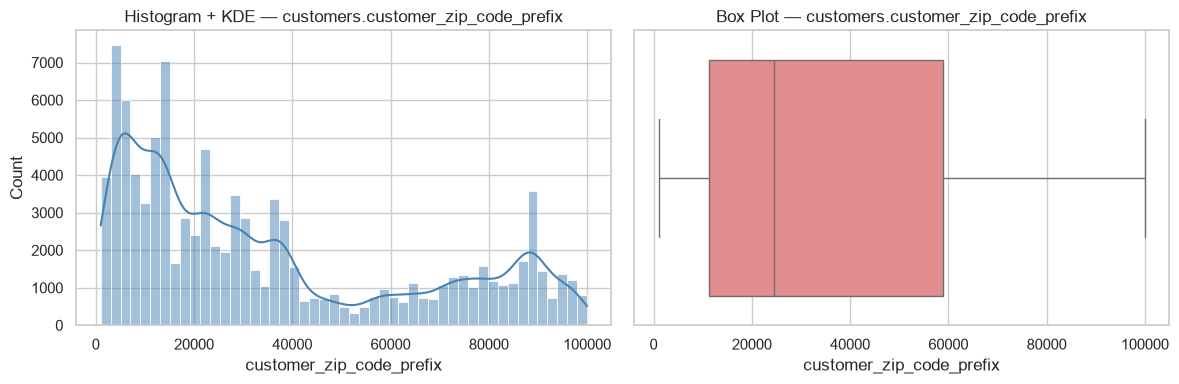


--- Outlier Analysis ---


,column,iqr_outliers,iqr_outlier_pct,zscore_outliers,zscore_outlier_pct
0,customer_zip_code_prefix,0,0.0,0,0.0



--- Correlation Analysis ---
Not enough numerical columns with variance for correlation analysis.

--- Datetime Analysis ---
No datetime columns detected.

--- Text Analysis ---

--- customer_id ---
Avg length: 32.0 | Max: 32 | Min: 32


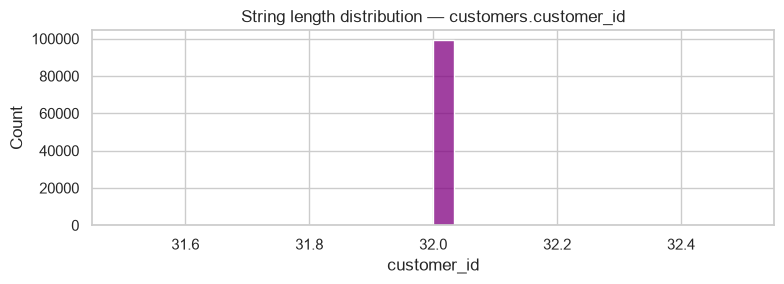


--- customer_unique_id ---
Avg length: 32.0 | Max: 32 | Min: 32


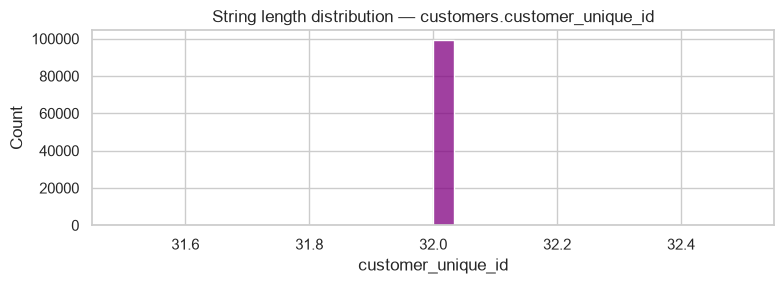


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'customers' contains 99,441 rows and 5 columns.


In [8]:
result = run_full_eda("customers", dataframes.get("customers"), ['customer_id'])
if result is not None:
    customers, customers_col_types = result


## 6.2. EDA — `orders`


### Detected column types:
  numerical: []
  categorical: ['order_status']
  datetime: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
  boolean: []
  text: ['order_id', 'customer_id']

--- Table Overview ---
TABLE OVERVIEW: orders
Shape: 99,441 rows x 8 columns
Memory usage: 25.85 MB

Column dtypes:
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

Sample records:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26



Unique value counts per column:


,n_unique
order_id,99441
customer_id,99441
order_purchase_timestamp,98875
order_delivered_customer_date,95664
order_approved_at,90733
order_delivered_carrier_date,81018
order_estimated_delivery_date,459
order_status,8



--- Missing Values ---


,null_count,null_pct
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


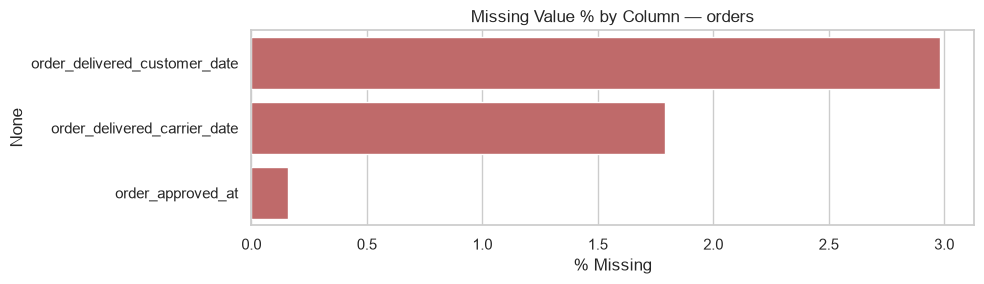

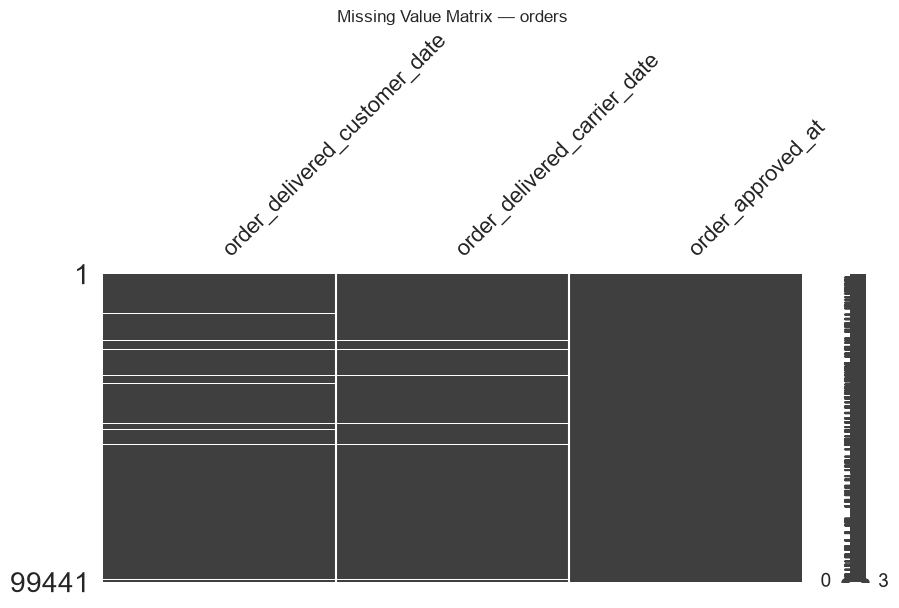


--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (order_id): 0

--- Categorical Analysis ---

--- order_status (8 unique values) ---


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



--- Numerical Analysis ---
No numerical columns detected.

--- Distribution Analysis ---

--- Outlier Analysis ---

--- Correlation Analysis ---
Not enough numerical columns with variance for correlation analysis.

--- Datetime Analysis ---

--- order_purchase_timestamp ---
Range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


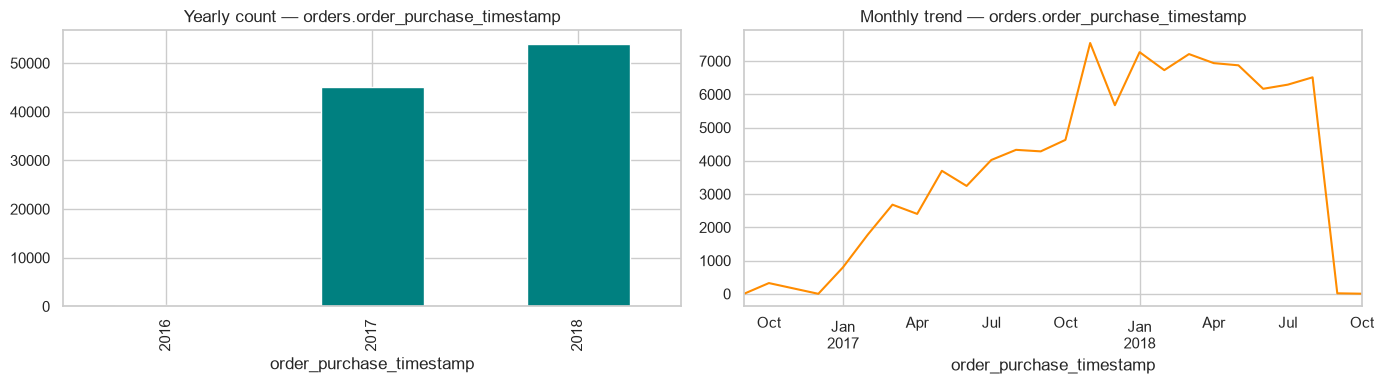


--- order_approved_at ---
Range: 2016-09-15 12:16:38 to 2018-09-03 17:40:06


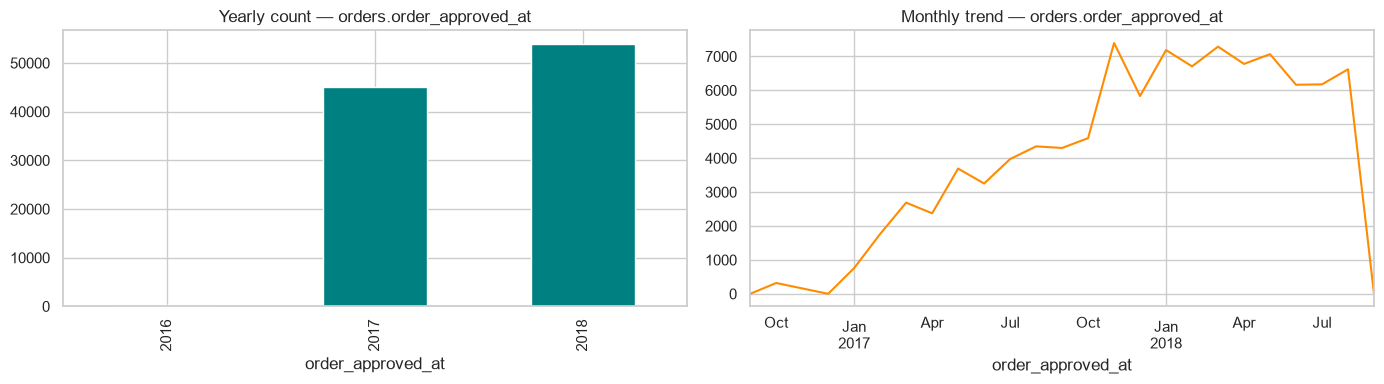


--- order_delivered_carrier_date ---
Range: 2016-10-08 10:34:01 to 2018-09-11 19:48:28


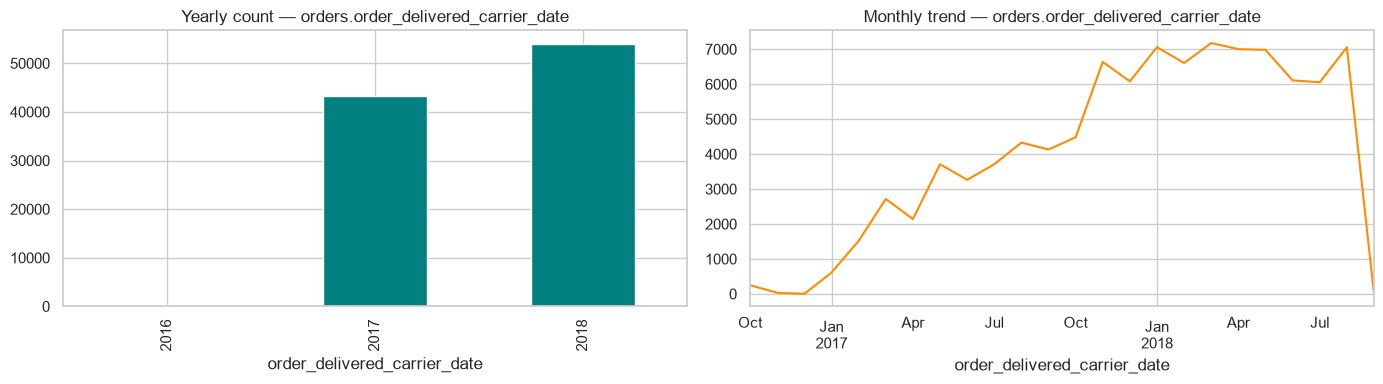


--- order_delivered_customer_date ---
Range: 2016-10-11 13:46:32 to 2018-10-17 13:22:46


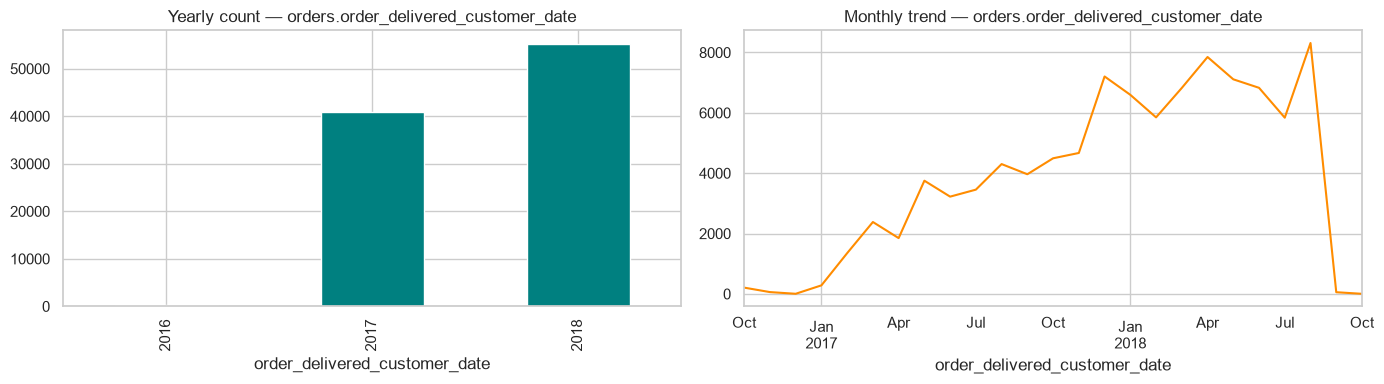


--- order_estimated_delivery_date ---
Range: 2016-09-30 00:00:00 to 2018-11-12 00:00:00


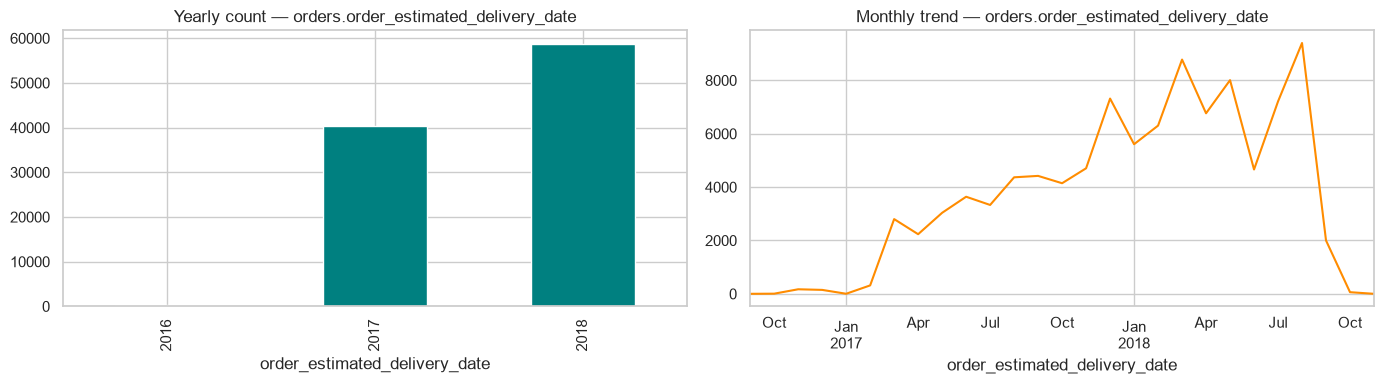


--- Text Analysis ---

--- order_id ---
Avg length: 32.0 | Max: 32 | Min: 32


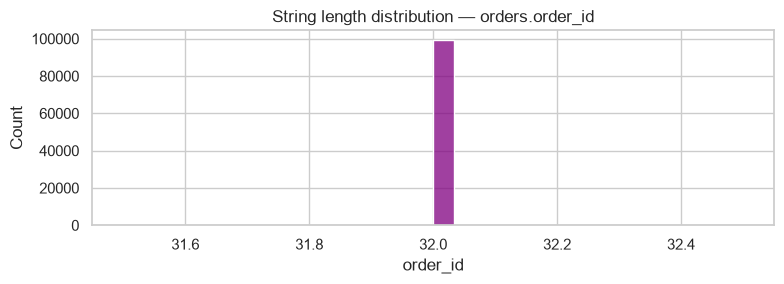


--- customer_id ---
Avg length: 32.0 | Max: 32 | Min: 32


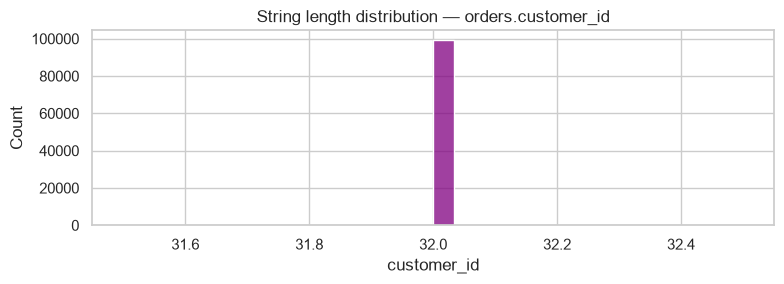


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'orders' contains 99,441 rows and 8 columns.
• Column 'order_status' is dominated by a single value ('delivered', 97.0% of rows).


In [9]:
result = run_full_eda("orders", dataframes.get("orders"), ['order_id'])
if result is not None:
    orders, orders_col_types = result


## 6.3. EDA — `order_items`


### Detected column types:
  numerical: ['order_item_id', 'price', 'freight_value']
  categorical: ['seller_id']
  datetime: ['shipping_limit_date']
  boolean: []
  text: ['order_id', 'product_id']

--- Table Overview ---
TABLE OVERVIEW: order_items
Shape: 112,650 rows x 7 columns
Memory usage: 30.98 MB

Column dtypes:
order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

Sample records:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Unique value counts per column:


,n_unique
order_id,98666
shipping_limit_date,93318
product_id,32951
freight_value,6999
price,5968
seller_id,3095
order_item_id,21



--- Missing Values ---
✅ No missing values detected in 'order_items'.

--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (order_id, order_item_id): 0

--- Categorical Analysis ---

--- seller_id (3095 unique values) ---


,count
seller_id,
6560211a19b47992c3666cc44a7e94c0,2033
4a3ca9315b744ce9f8e9374361493884,1987
1f50f920176fa81dab994f9023523100,1931
cc419e0650a3c5ba77189a1882b7556a,1775
da8622b14eb17ae2831f4ac5b9dab84a,1551
955fee9216a65b617aa5c0531780ce60,1499
1025f0e2d44d7041d6cf58b6550e0bfa,1428
7c67e1448b00f6e969d365cea6b010ab,1364
ea8482cd71df3c1969d7b9473ff13abc,1203



--- Numerical Analysis ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00,7.580356,103.857361
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00,7.923208,120.828298
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68,5.639870,59.788253



--- Distribution Analysis ---


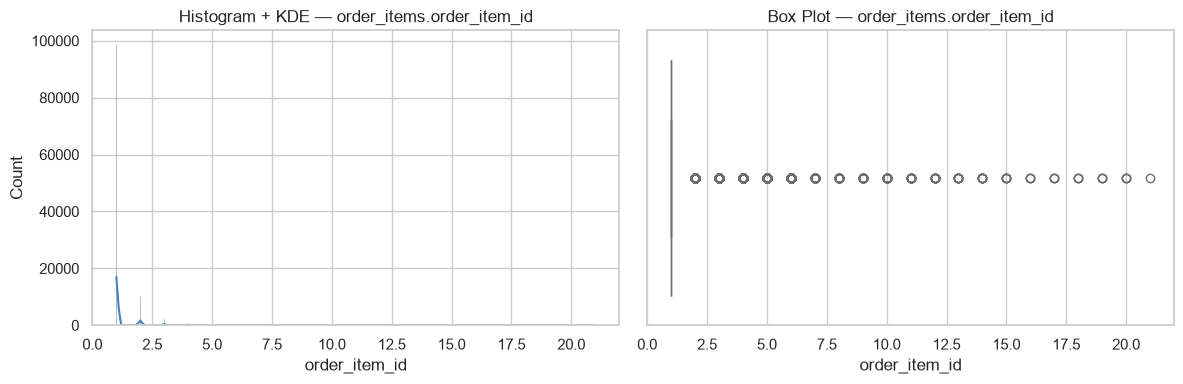

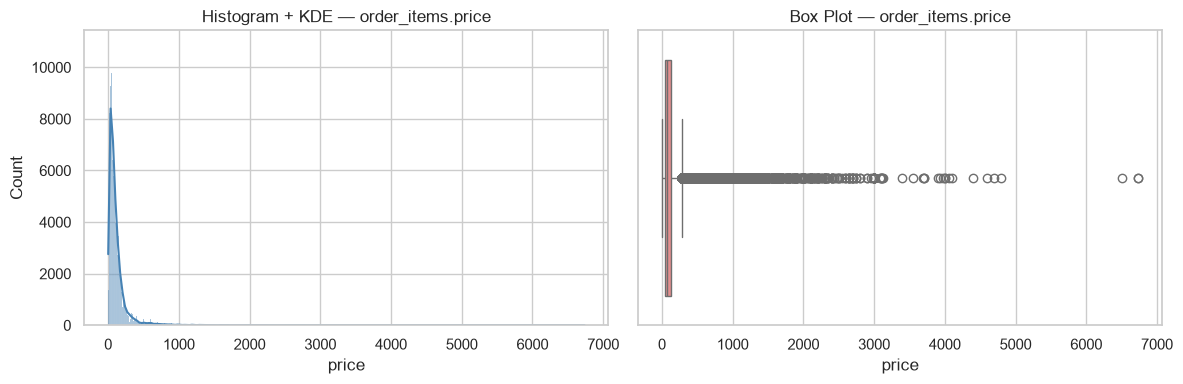

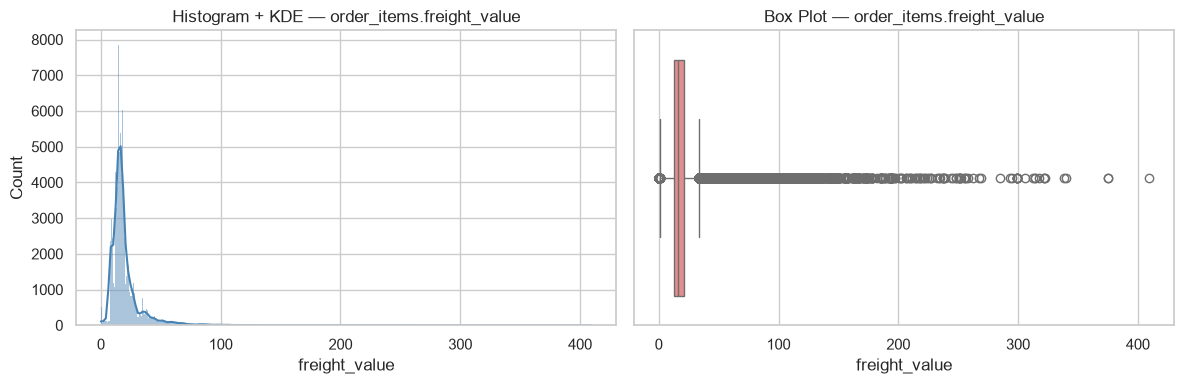


--- Outlier Analysis ---


,column,iqr_outliers,iqr_outlier_pct,zscore_outliers,zscore_outlier_pct
0,order_item_id,13984,12.41,1894,1.68
1,price,8427,7.48,1966,1.75
2,freight_value,12134,10.77,2041,1.81



--- Correlation Analysis ---


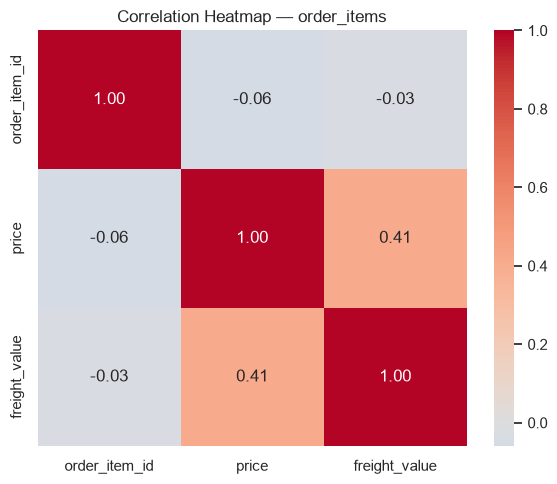

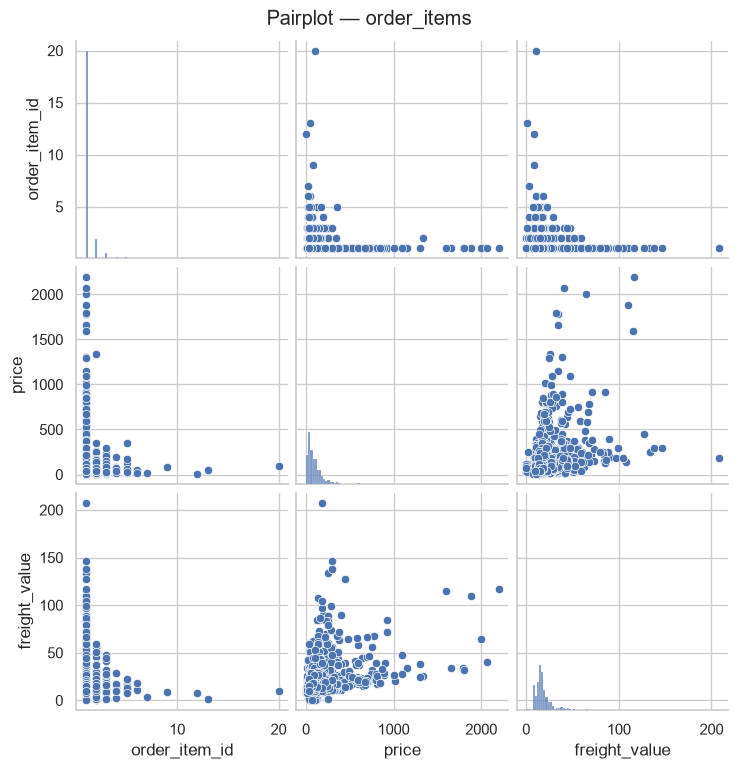


--- Datetime Analysis ---

--- shipping_limit_date ---
Range: 2016-09-19 00:15:34 to 2020-04-09 22:35:08


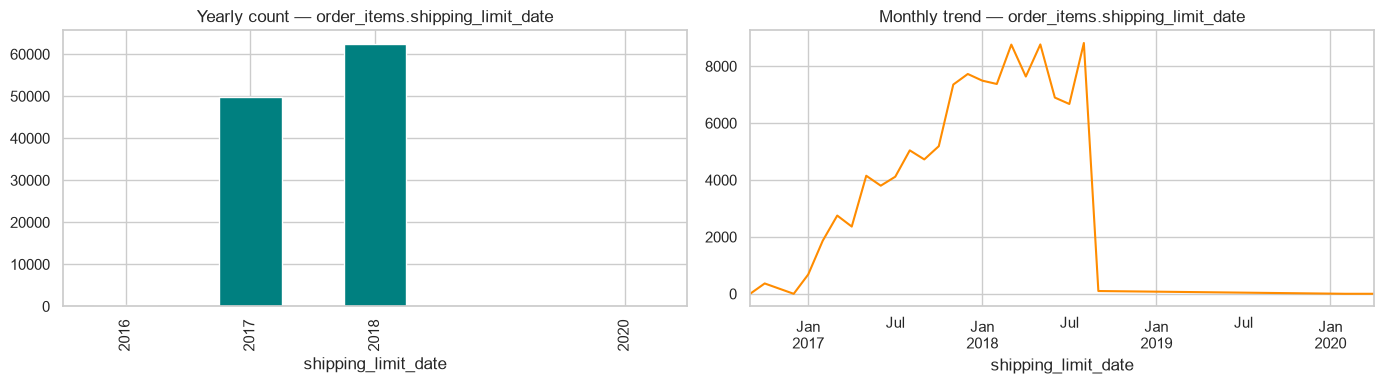


--- Text Analysis ---

--- order_id ---
Avg length: 32.0 | Max: 32 | Min: 32


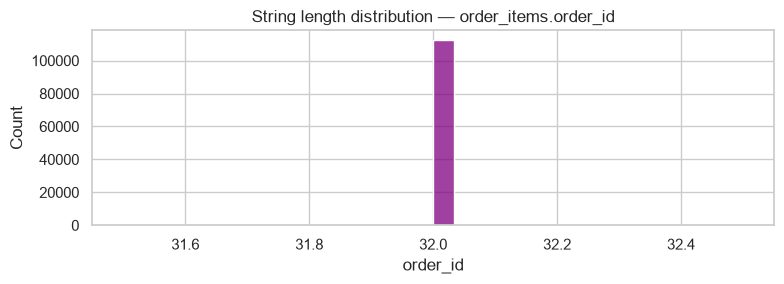


--- product_id ---
Avg length: 32.0 | Max: 32 | Min: 32


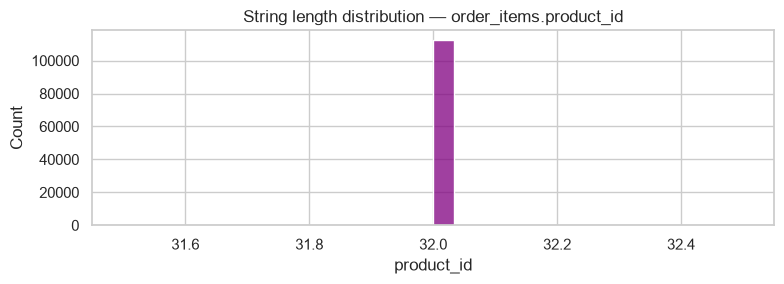


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'order_items' contains 112,650 rows and 7 columns.
• Column 'order_item_id' is highly right-skewed (skew=7.58).
• Column 'price' is highly right-skewed (skew=7.92).
• Column 'freight_value' is highly right-skewed (skew=5.64).


In [10]:
result = run_full_eda("order_items", dataframes.get("order_items"), ['order_id', 'order_item_id'])
if result is not None:
    order_items, order_items_col_types = result


## 6.4. EDA — `order_payments`


### Detected column types:
  numerical: ['payment_sequential', 'payment_installments', 'payment_value']
  categorical: ['payment_type']
  datetime: []
  boolean: []
  text: ['order_id']

--- Table Overview ---
TABLE OVERVIEW: order_payments
Shape: 103,886 rows x 5 columns
Memory usage: 17.02 MB

Column dtypes:
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

Sample records:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Unique value counts per column:


,n_unique
order_id,99440
payment_value,29077
payment_sequential,29
payment_installments,24
payment_type,5



--- Missing Values ---
✅ No missing values detected in 'order_payments'.

--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (order_id, payment_sequential): 0

--- Categorical Analysis ---

--- payment_type (5 unique values) ---


,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3



--- Numerical Analysis ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
payment_sequential,103886.0,1.092679,0.706584,1.0,1.00,1.0,1.0000,29.00,16.180065,370.593809
payment_installments,103886.0,2.853349,2.687051,0.0,1.00,1.0,4.0000,24.00,1.655074,2.550048
payment_value,103886.0,154.100380,217.494064,0.0,56.79,100.0,171.8375,13664.08,9.254010,241.828442



--- Distribution Analysis ---


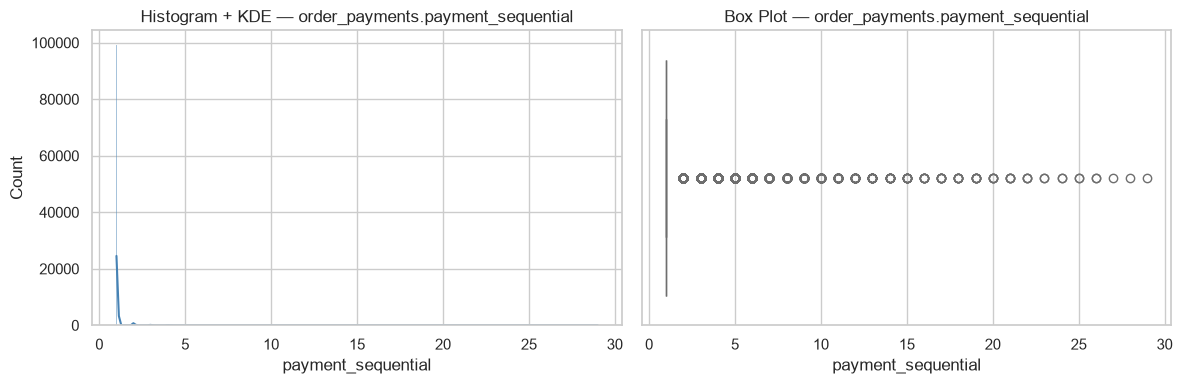

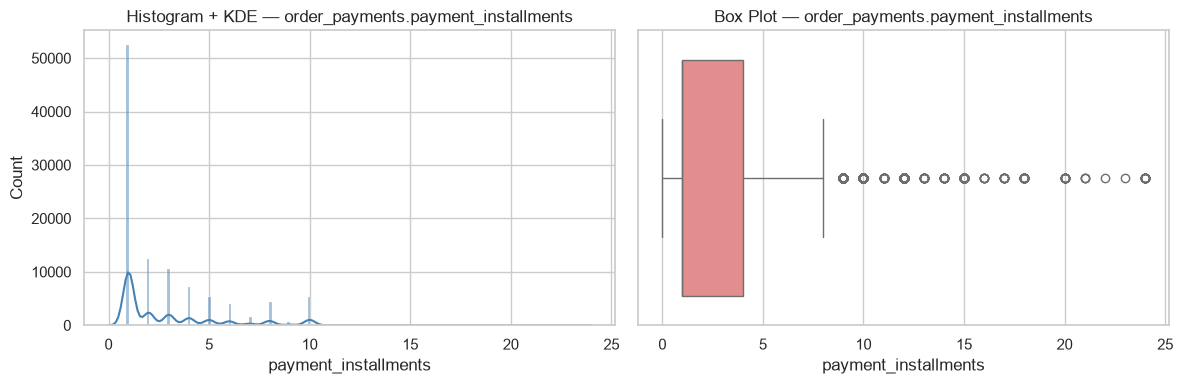

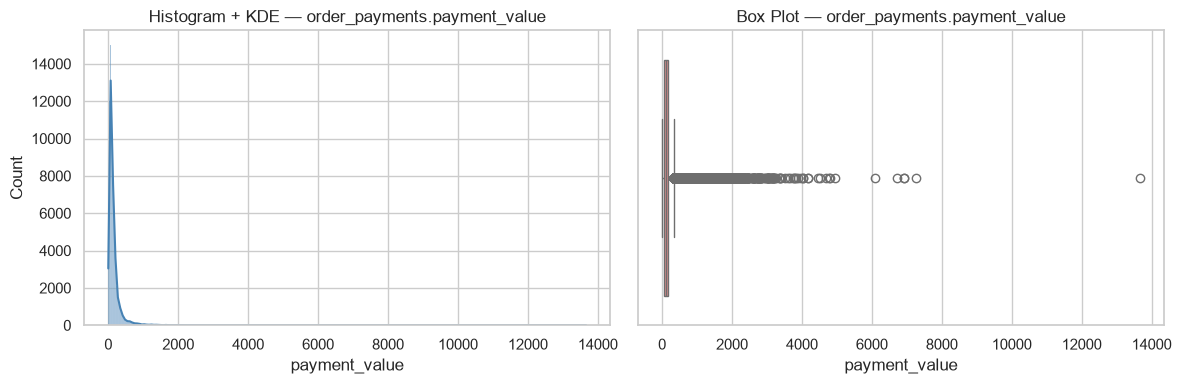


--- Outlier Analysis ---


,column,iqr_outliers,iqr_outlier_pct,zscore_outliers,zscore_outlier_pct
0,payment_sequential,4526,4.36,906,0.87
1,payment_installments,6313,6.08,341,0.33
2,payment_value,7981,7.68,1803,1.74



--- Correlation Analysis ---


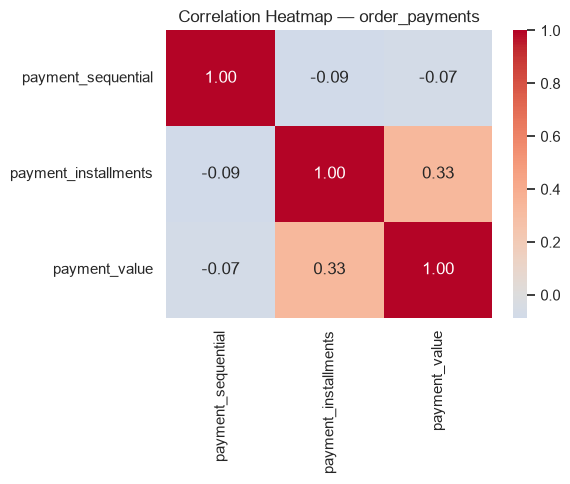

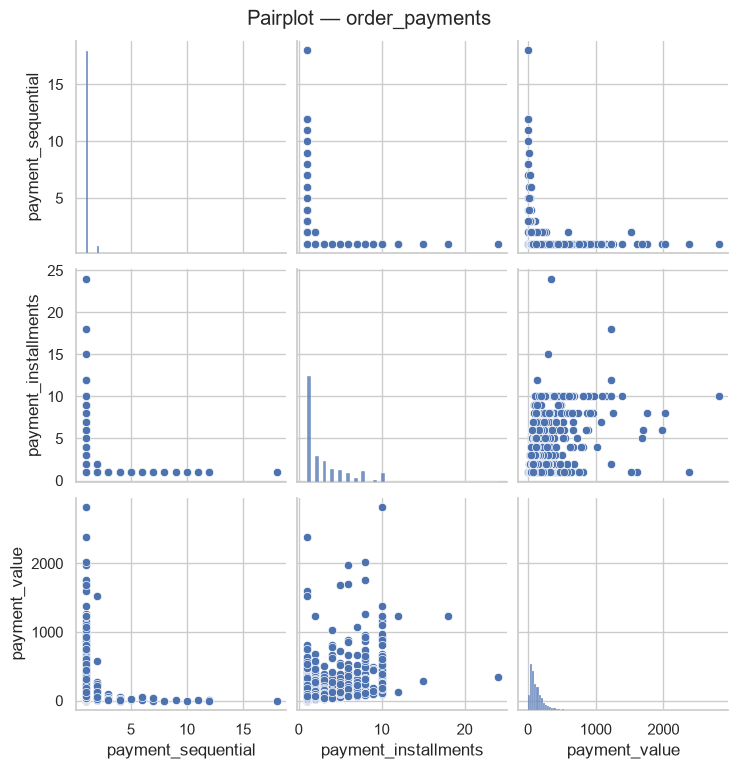


--- Datetime Analysis ---
No datetime columns detected.

--- Text Analysis ---

--- order_id ---
Avg length: 32.0 | Max: 32 | Min: 32


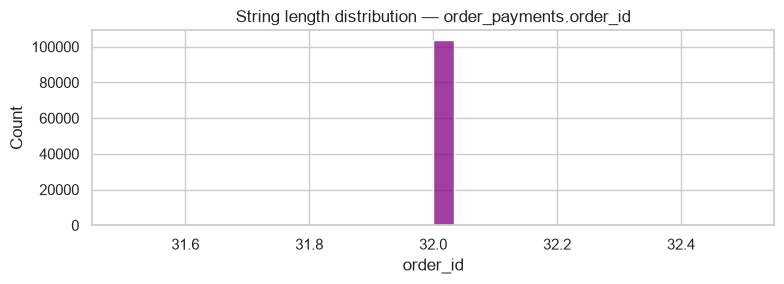


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'order_payments' contains 103,886 rows and 5 columns.
• Column 'payment_type' is dominated by a single value ('credit_card', 73.9% of rows).
• Column 'payment_sequential' is highly right-skewed (skew=16.18).
• Column 'payment_installments' is highly right-skewed (skew=1.66).
• Column 'payment_value' is highly right-skewed (skew=9.25).


In [11]:
result = run_full_eda("order_payments", dataframes.get("order_payments"), ['order_id', 'payment_sequential'])
if result is not None:
    order_payments, order_payments_col_types = result


## 6.5. EDA — `order_reviews`


### Detected column types:
  numerical: ['review_score']
  categorical: []
  datetime: ['review_creation_date', 'review_answer_timestamp']
  boolean: []
  text: ['review_id', 'order_id', 'review_comment_title', 'review_comment_message']

--- Table Overview ---
TABLE OVERVIEW: order_reviews
Shape: 2,872 rows x 7 columns
Memory usage: 0.85 MB

Column dtypes:
review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

Sample records:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53



Unique value counts per column:


,n_unique
review_id,2872
review_answer_timestamp,2872
order_id,2871
review_comment_message,1178
review_creation_date,502
review_comment_title,228
review_score,5



--- Missing Values ---


,null_count,null_pct
review_comment_title,2537,88.34
review_comment_message,1657,57.69


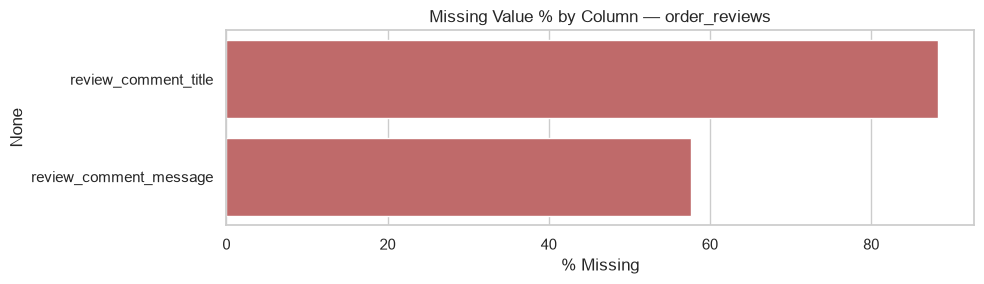

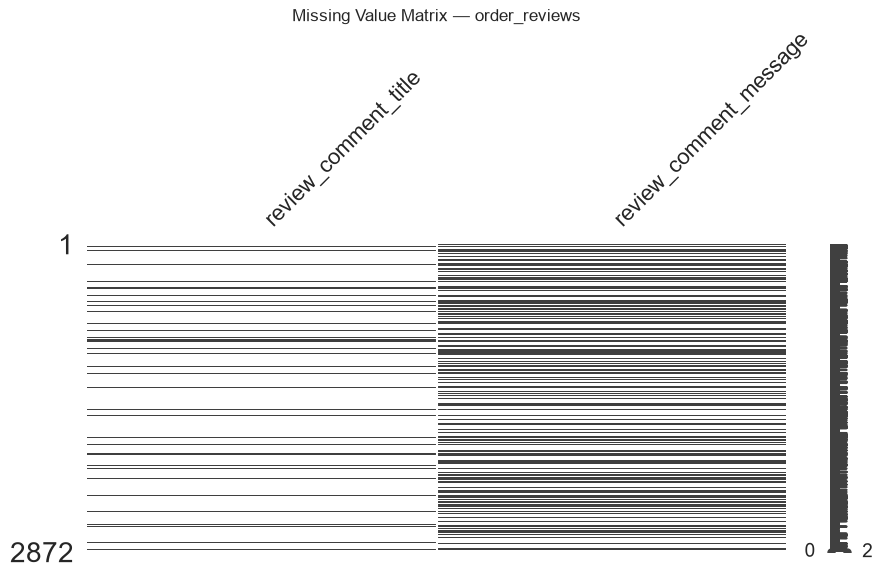


--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (review_id): 0

--- Categorical Analysis ---
No categorical columns detected.

--- Numerical Analysis ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
review_score,2872.0,4.133705,1.322139,1.0,4.0,5.0,5.0,5.0,-1.438439,0.746661



--- Distribution Analysis ---


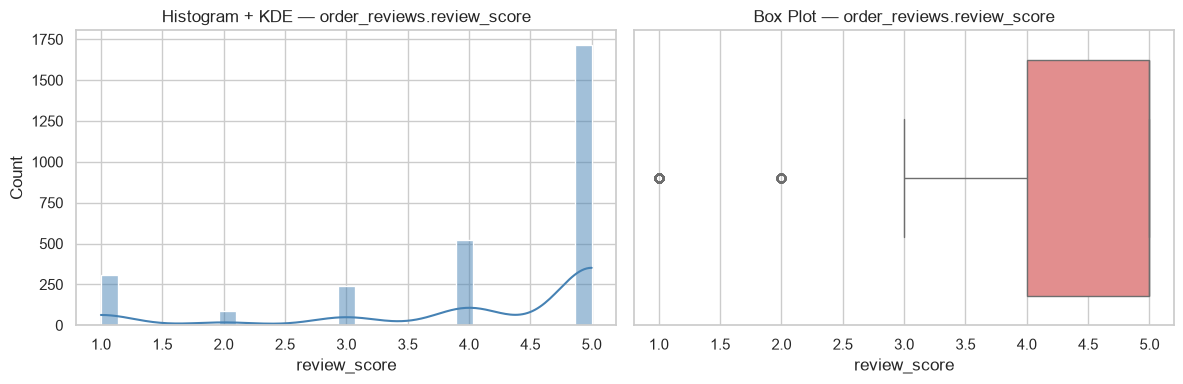


--- Outlier Analysis ---


,column,iqr_outliers,iqr_outlier_pct,zscore_outliers,zscore_outlier_pct
0,review_score,393,13.68,0,0.0



--- Correlation Analysis ---
Not enough numerical columns with variance for correlation analysis.

--- Datetime Analysis ---

--- review_creation_date ---
Range: 2016-10-19 00:00:00 to 2018-08-31 00:00:00


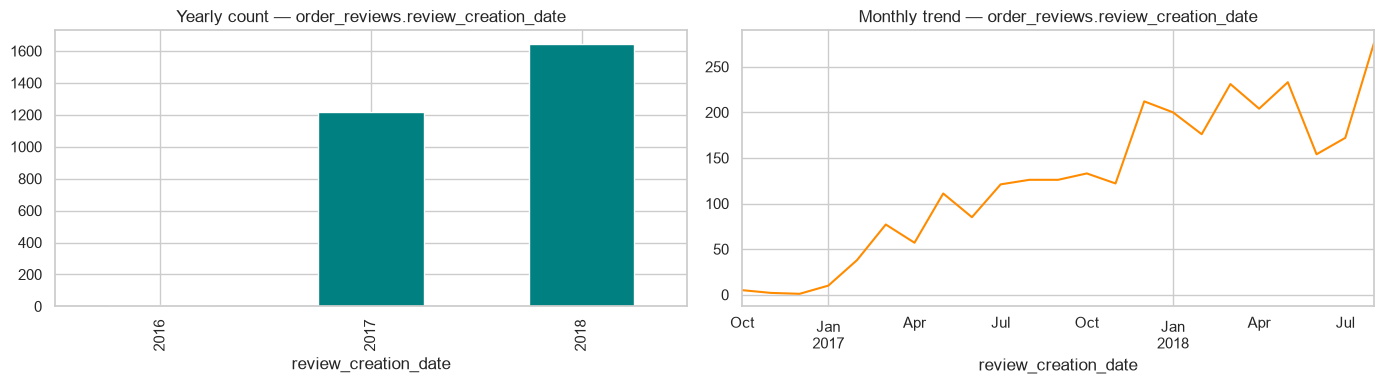


--- review_answer_timestamp ---
Range: 2016-10-20 12:40:59 to 2018-09-26 01:49:08


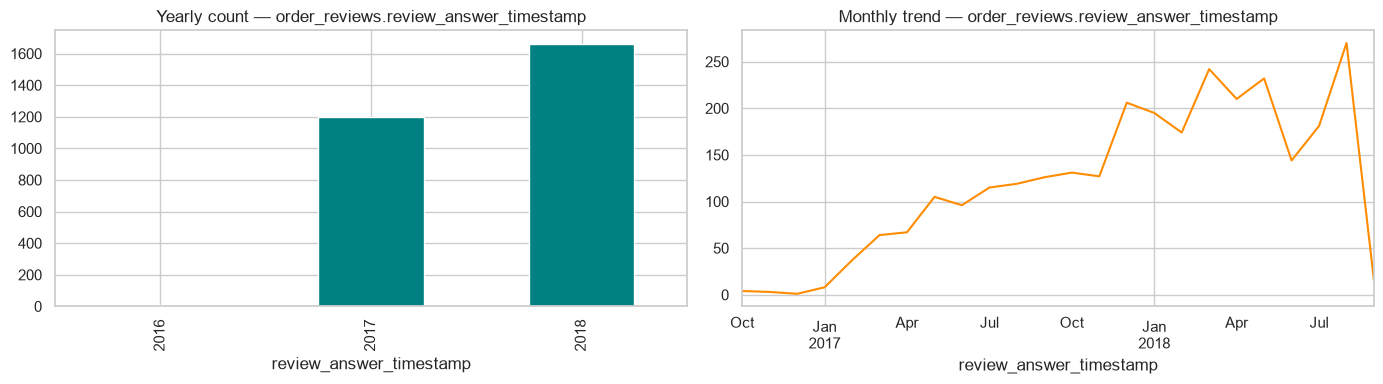


--- Text Analysis ---

--- review_id ---
Avg length: 32.0 | Max: 32 | Min: 32


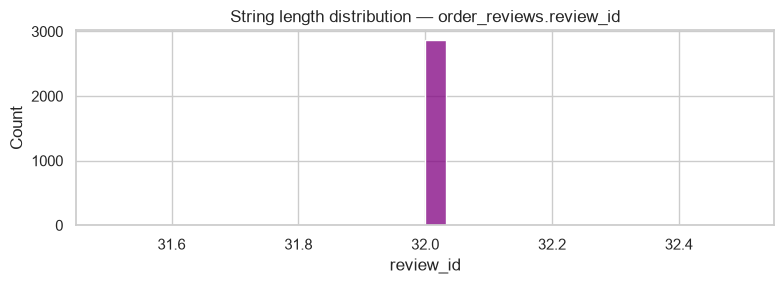


--- order_id ---
Avg length: 32.0 | Max: 32 | Min: 32


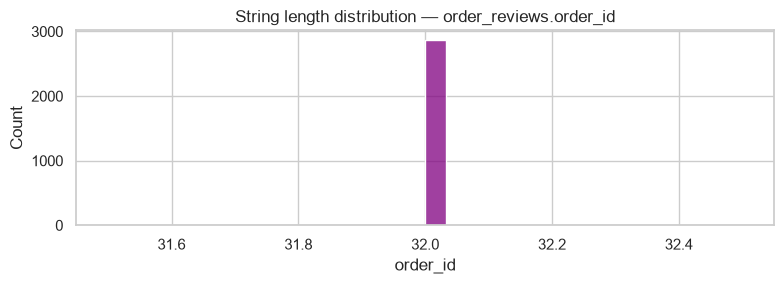


--- review_comment_title ---
Avg length: 11.9 | Max: 25 | Min: 1


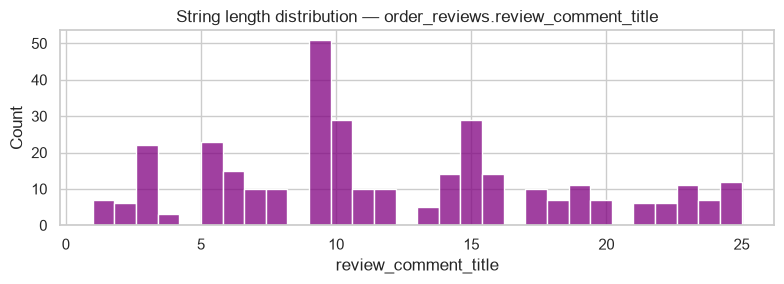


--- review_comment_message ---
Avg length: 67.8 | Max: 208 | Min: 1


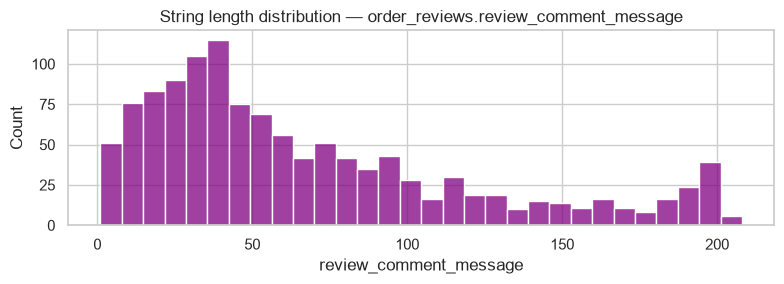


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'order_reviews' contains 2,872 rows and 7 columns.
• Columns with >20% missing data: review_comment_title, review_comment_message.
• Column 'review_score' is highly left-skewed (skew=-1.44).


In [12]:
result = run_full_eda("order_reviews", dataframes.get("order_reviews"), ['review_id'])
if result is not None:
    order_reviews, order_reviews_col_types = result


## 6.6. EDA — `products`


### Detected column types:
  numerical: ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
  categorical: ['product_category_name']
  datetime: []
  boolean: []
  text: ['product_id']

--- Table Overview ---
TABLE OVERVIEW: products
Shape: 32,951 rows x 9 columns
Memory usage: 6.60 MB

Column dtypes:
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Sample records:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Unique value counts per column:


,n_unique
product_id,32951
product_description_lenght,2960
product_weight_g,2204
product_height_cm,102
product_length_cm,99
product_width_cm,95
product_category_name,73
product_name_lenght,66
product_photos_qty,19



--- Missing Values ---


,null_count,null_pct
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


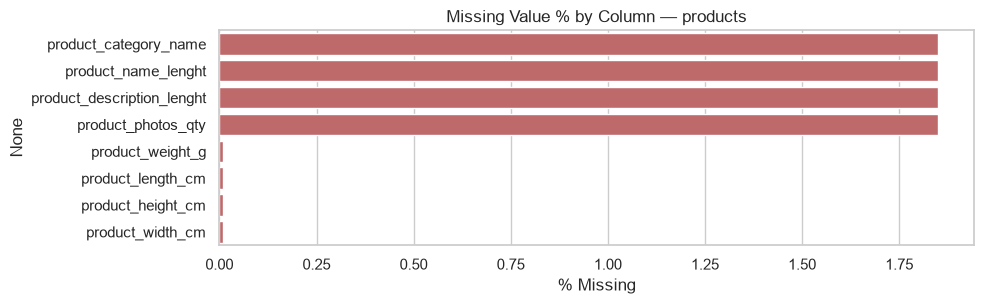

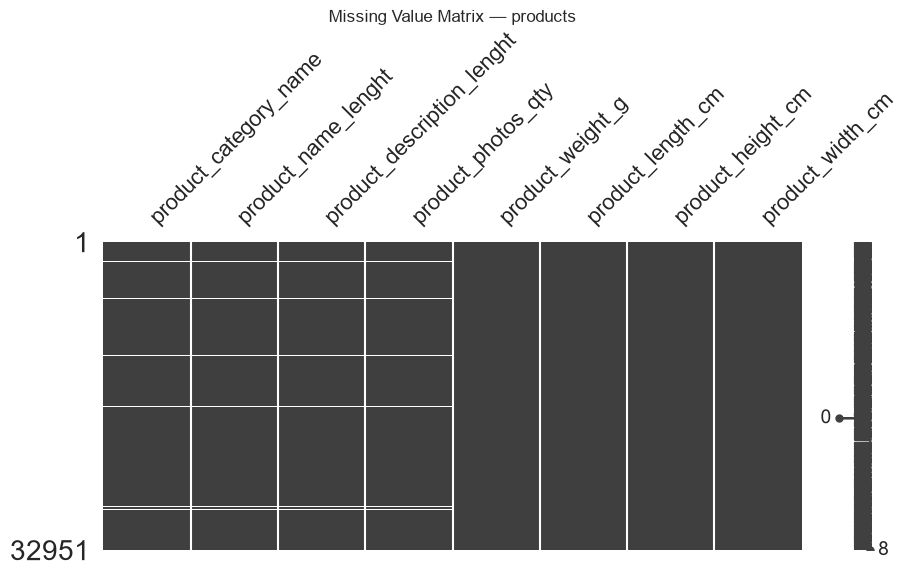


--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (product_id): 0

--- Categorical Analysis ---

--- product_category_name (73 unique values) ---


,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329



--- Numerical Analysis ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
product_name_lenght,32341.0,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0,-0.903222,0.192563
product_description_lenght,32341.0,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0,1.962093,4.828923
product_photos_qty,32341.0,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0,2.193409,7.263534
product_weight_g,32949.0,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0,3.604860,15.133565
product_length_cm,32949.0,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0,1.750460,3.513618
product_height_cm,32949.0,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0,2.140061,6.678619
product_width_cm,32949.0,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0,1.670971,4.073126



--- Distribution Analysis ---


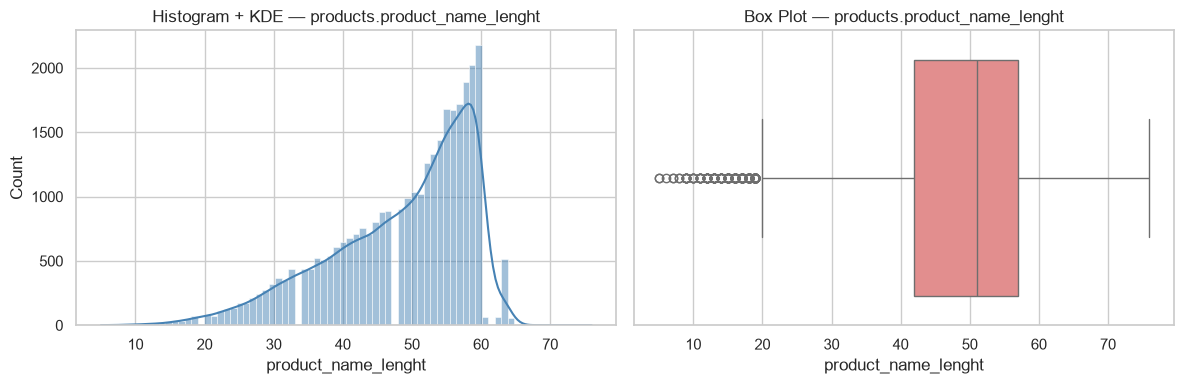

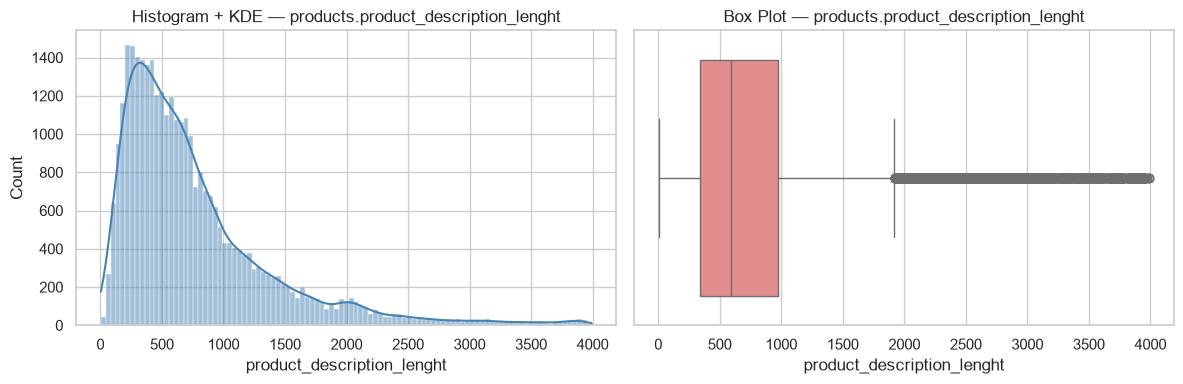

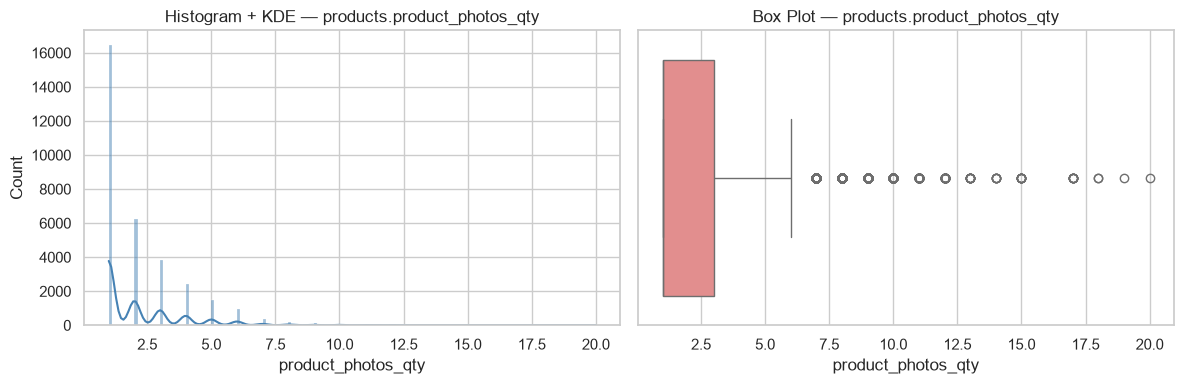

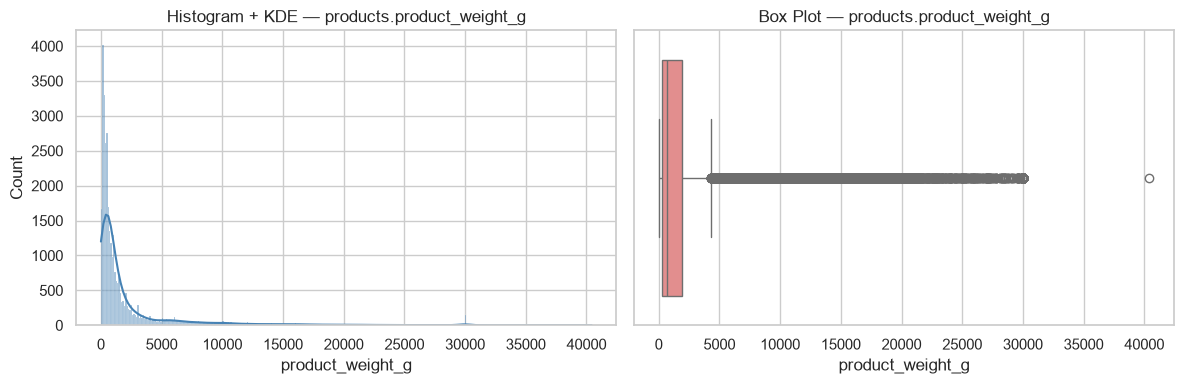

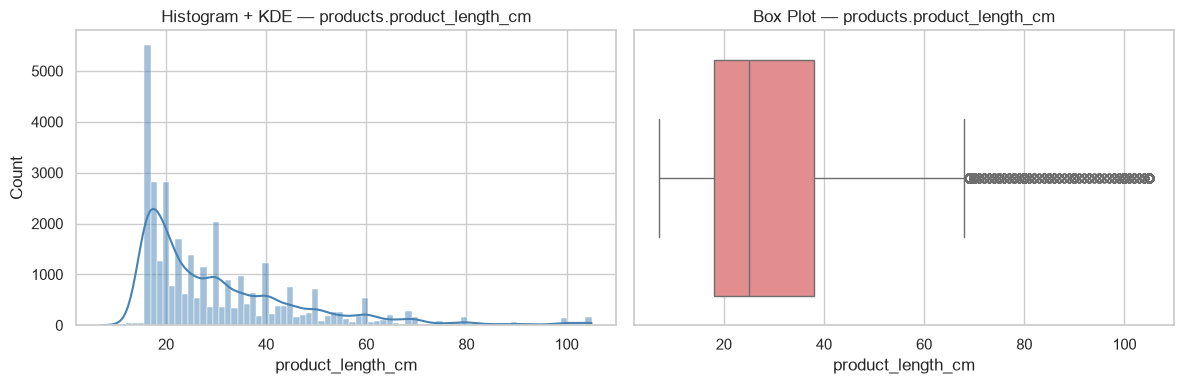

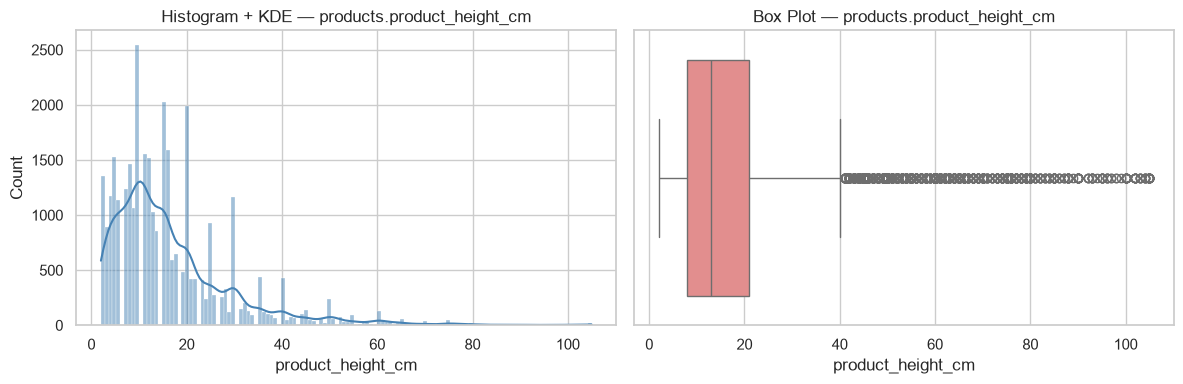

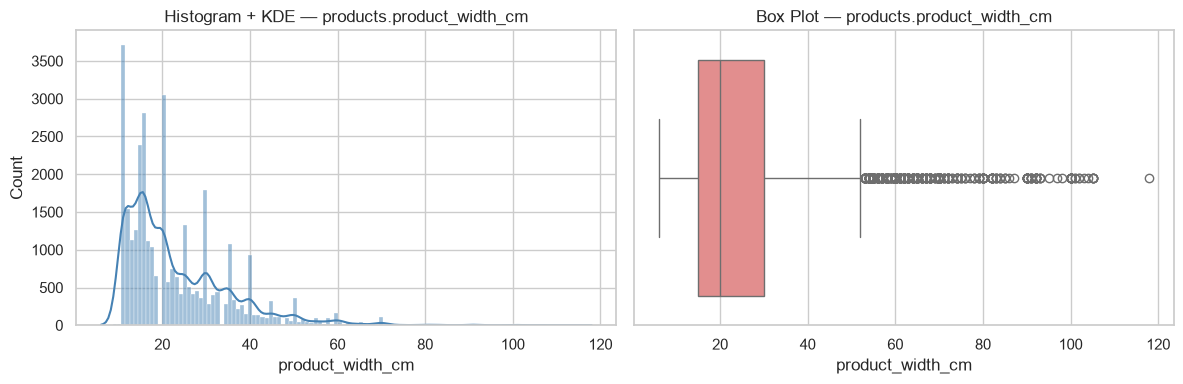


--- Outlier Analysis ---


,column,iqr_outliers,iqr_outlier_pct,zscore_outliers,zscore_outlier_pct
0,product_name_lenght,290,0.90,167,0.52
1,product_description_lenght,2078,6.43,696,2.15
2,product_photos_qty,849,2.63,506,1.56
3,product_weight_g,4551,13.81,961,2.92
4,product_length_cm,1380,4.19,616,1.87
5,product_height_cm,1892,5.74,728,2.21
6,product_width_cm,912,2.77,574,1.74



--- Correlation Analysis ---


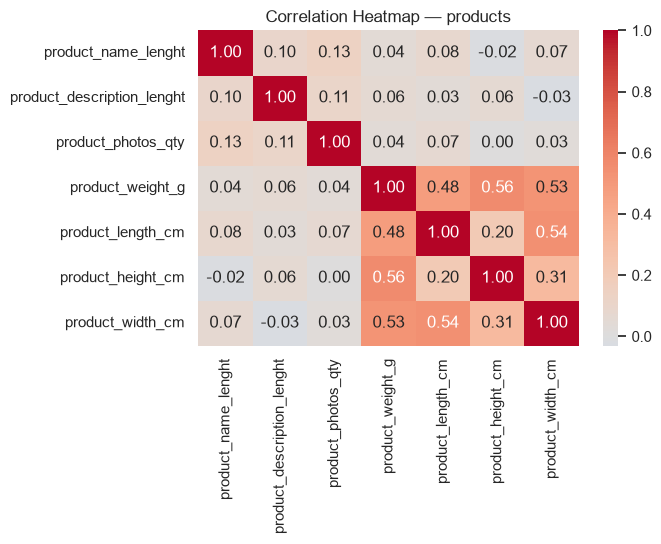


--- Datetime Analysis ---
No datetime columns detected.

--- Text Analysis ---

--- product_id ---
Avg length: 32.0 | Max: 32 | Min: 32


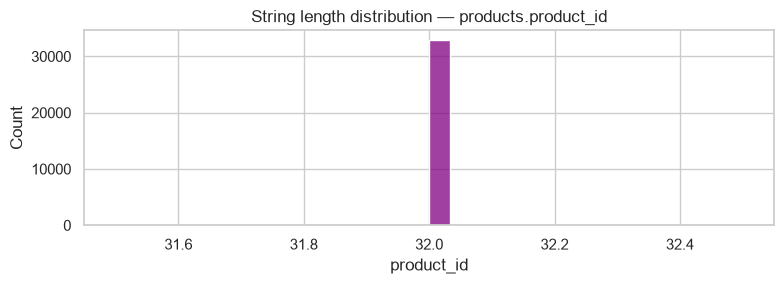


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'products' contains 32,951 rows and 9 columns.
• Column 'product_description_lenght' is highly right-skewed (skew=1.96).
• Column 'product_photos_qty' is highly right-skewed (skew=2.19).
• Column 'product_weight_g' is highly right-skewed (skew=3.60).
• Column 'product_length_cm' is highly right-skewed (skew=1.75).
• Column 'product_height_cm' is highly right-skewed (skew=2.14).
• Column 'product_width_cm' is highly right-skewed (skew=1.67).


In [13]:
result = run_full_eda("products", dataframes.get("products"), ['product_id'])
if result is not None:
    products, products_col_types = result


## 6.7. EDA — `sellers`


### Detected column types:
  numerical: ['seller_zip_code_prefix']
  categorical: ['seller_state']
  datetime: []
  boolean: []
  text: ['seller_id', 'seller_city']

--- Table Overview ---
TABLE OVERVIEW: sellers
Shape: 3,095 rows x 4 columns
Memory usage: 0.62 MB

Column dtypes:
seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

Sample records:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Unique value counts per column:


,n_unique
seller_id,3095
seller_zip_code_prefix,2246
seller_city,611
seller_state,23



--- Missing Values ---
✅ No missing values detected in 'sellers'.

--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (seller_id): 0

--- Categorical Analysis ---

--- seller_state (23 unique values) ---


,count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23



--- Numerical Analysis ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0,0.916092,-0.858264



--- Distribution Analysis ---


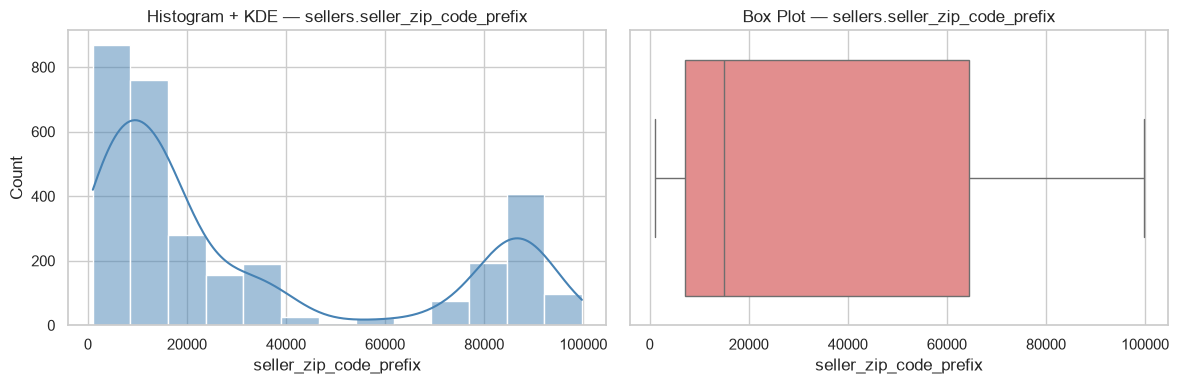


--- Outlier Analysis ---


,column,iqr_outliers,iqr_outlier_pct,zscore_outliers,zscore_outlier_pct
0,seller_zip_code_prefix,0,0.0,0,0.0



--- Correlation Analysis ---
Not enough numerical columns with variance for correlation analysis.

--- Datetime Analysis ---
No datetime columns detected.

--- Text Analysis ---

--- seller_id ---
Avg length: 32.0 | Max: 32 | Min: 32


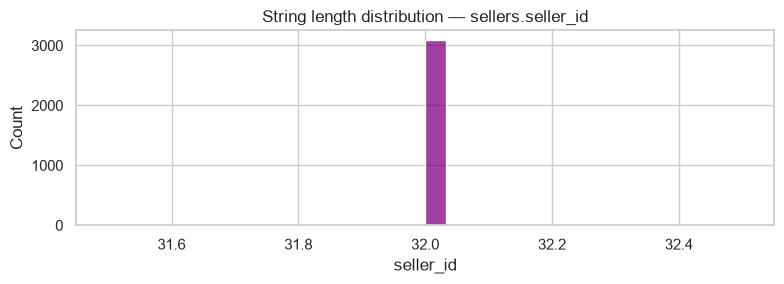


--- seller_city ---
Avg length: 10.2 | Max: 40 | Min: 2


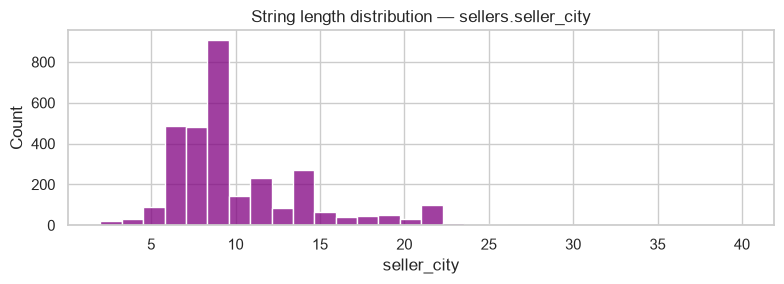


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'sellers' contains 3,095 rows and 4 columns.
• Column 'seller_state' is dominated by a single value ('SP', 59.7% of rows).


In [14]:
result = run_full_eda("sellers", dataframes.get("sellers"), ['seller_id'])
if result is not None:
    sellers, sellers_col_types = result


## 6.8. EDA — `product_category_name_translation`


### Detected column types:
  numerical: []
  categorical: []
  datetime: []
  boolean: []
  text: ['product_category_name', 'product_category_name_english']

--- Table Overview ---
TABLE OVERVIEW: product_category_name_translation
Shape: 71 rows x 2 columns
Memory usage: 0.01 MB

Column dtypes:
product_category_name            str
product_category_name_english    str
dtype: object

Sample records:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



Unique value counts per column:


,n_unique
product_category_name,71
product_category_name_english,71



--- Missing Values ---
✅ No missing values detected in 'product_category_name_translation'.

--- Duplicates ---
Fully duplicated rows: 0
Duplicate primary keys (product_category_name): 0

--- Categorical Analysis ---
No categorical columns detected.

--- Numerical Analysis ---
No numerical columns detected.

--- Distribution Analysis ---

--- Outlier Analysis ---

--- Correlation Analysis ---
Not enough numerical columns with variance for correlation analysis.

--- Datetime Analysis ---
No datetime columns detected.

--- Text Analysis ---

--- product_category_name ---
Avg length: 17.0 | Max: 46 | Min: 3


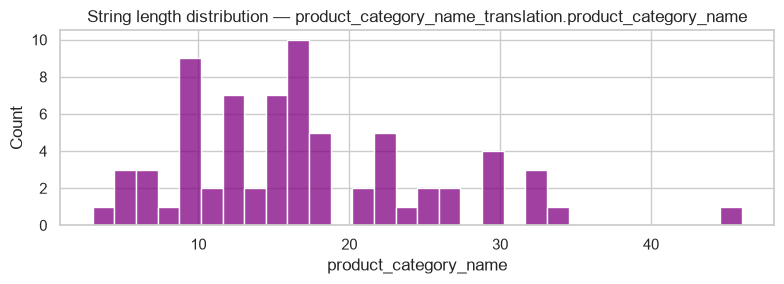


--- product_category_name_english ---
Avg length: 16.1 | Max: 39 | Min: 3


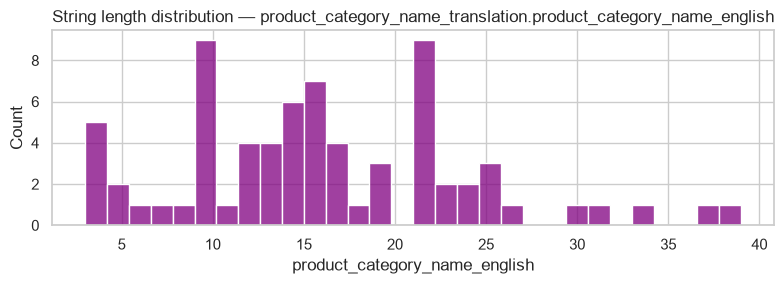


--- Data Quality Checks ---
✅ No obvious data quality issues detected.

--- Key Insights ---
• 'product_category_name_translation' contains 71 rows and 2 columns.


In [15]:
result = run_full_eda("product_category_name_translation", dataframes.get("product_category_name_translation"), ['product_category_name'])
if result is not None:
    product_category_name_translation, product_category_name_translation_col_types = result


## 7. Cross-Table & Relationship Analysis

In [16]:
def relationship_analysis(child_name, child_df, fk_col, parent_name, parent_df, pk_col):
    """Validate a foreign-key relationship: orphan records, join completeness, cardinality."""
    if child_df is None or parent_df is None:
        print(f"⚠️ Skipping {child_name}.{fk_col} -> {parent_name}.{pk_col} (missing table).")
        return

    if fk_col not in child_df.columns or pk_col not in parent_df.columns:
        print(f"⚠️ Skipping — column not found.")
        return

    child_keys = set(child_df[fk_col].dropna().unique())
    parent_keys = set(parent_df[pk_col].dropna().unique())

    orphans = child_keys - parent_keys
    orphan_rows = child_df[fk_col].isin(orphans).sum()
    match_rate = 100 * (1 - len(orphans) / max(len(child_keys), 1))

    print(f"\n{'='*70}\n{child_name}.{fk_col}  ->  {parent_name}.{pk_col}\n{'='*70}")
    print(f"Distinct FK values in child: {len(child_keys):,}")
    print(f"Distinct PK values in parent: {len(parent_keys):,}")
    print(f"Orphan FK values (no matching parent): {len(orphans):,}")
    print(f"Orphan rows in child table: {orphan_rows:,}")
    print(f"Join completeness: {match_rate:.2f}%")

    parent_counts = child_df[fk_col].value_counts()
    print(f"Avg child rows per parent: {parent_counts.mean():.2f} | Max: {parent_counts.max()}")


for rel in RELATIONSHIPS:
    relationship_analysis(
        rel["child"], dataframes.get(rel["child"]), rel["fk"],
        rel["parent"], dataframes.get(rel["parent"]), rel["pk"]
    )



orders.customer_id  ->  customers.customer_id
Distinct FK values in child: 99,441
Distinct PK values in parent: 99,441
Orphan FK values (no matching parent): 0
Orphan rows in child table: 0
Join completeness: 100.00%
Avg child rows per parent: 1.00 | Max: 1

order_items.order_id  ->  orders.order_id
Distinct FK values in child: 98,666
Distinct PK values in parent: 99,441
Orphan FK values (no matching parent): 0
Orphan rows in child table: 0
Join completeness: 100.00%
Avg child rows per parent: 1.14 | Max: 21

order_items.product_id  ->  products.product_id
Distinct FK values in child: 32,951
Distinct PK values in parent: 32,951
Orphan FK values (no matching parent): 0
Orphan rows in child table: 0
Join completeness: 100.00%
Avg child rows per parent: 3.42 | Max: 527

order_items.seller_id  ->  sellers.seller_id
Distinct FK values in child: 3,095
Distinct PK values in parent: 3,095
Orphan FK values (no matching parent): 0
Orphan rows in child table: 0
Join completeness: 100.00%
Avg chi

### 7.1. Orders + Customers — Geographic Distribution

In [17]:
if orders is not None and customers is not None:
    merged = orders.merge(customers, on="customer_id", how="left")
    state_counts = merged["customer_state"].value_counts().head(15)
    fig = px.bar(x=state_counts.index, y=state_counts.values,
                 title="Top 15 Customer States by Order Count",
                 labels={"x": "State", "y": "Order Count"})
    fig.show()
else:
    print("Required tables not available.")


### 7.2. Order Items + Products + Category Translation — Category Sales

In [18]:
if order_items is not None and products is not None:
    merged = order_items.merge(products, on="product_id", how="left")
    if product_category_name_translation is not None:
        merged = merged.merge(product_category_name_translation, on="product_category_name", how="left")
        cat_col = "product_category_name_english"
    else:
        cat_col = "product_category_name"

    cat_revenue = merged.groupby(cat_col)["price"].sum().sort_values(ascending=False).head(15)
    fig = px.bar(x=cat_revenue.values, y=cat_revenue.index, orientation="h",
                 title="Top 15 Product Categories by Revenue",
                 labels={"x": "Total Revenue", "y": "Category"})
    fig.update_layout(yaxis={"categoryorder": "total ascending"})
    fig.show()
else:
    print("Required tables not available.")


### 7.3. Order Payments — Payment Type & Installments

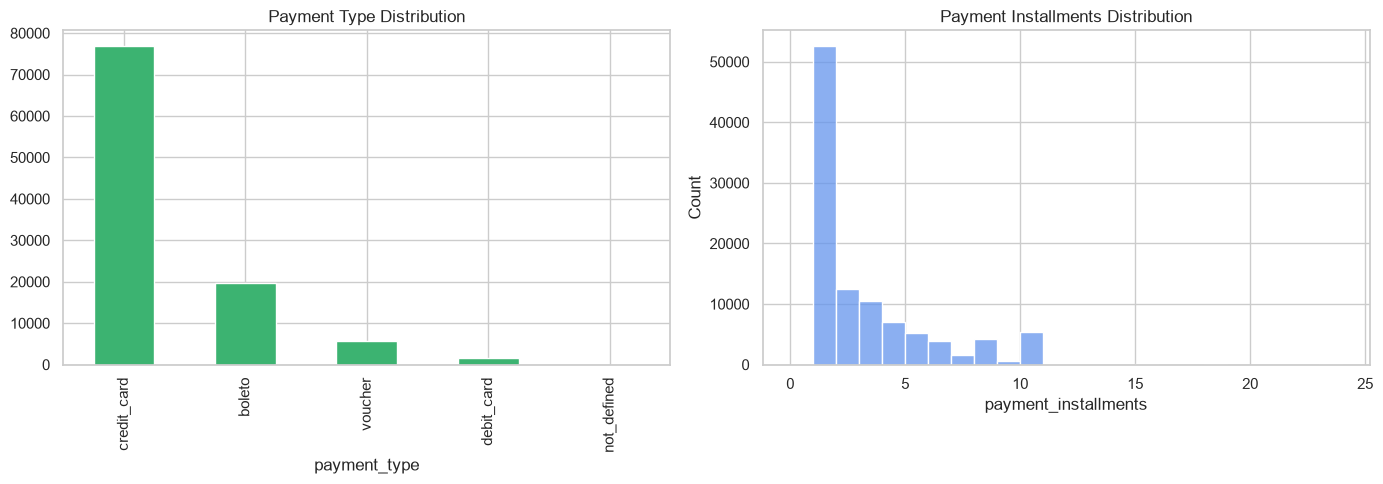

In [19]:
if order_payments is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    order_payments["payment_type"].value_counts().plot(kind="bar", ax=axes[0], color="mediumseagreen")
    axes[0].set_title("Payment Type Distribution")
    sns.histplot(order_payments["payment_installments"], bins=24, ax=axes[1], color="cornflowerblue")
    axes[1].set_title("Payment Installments Distribution")
    plt.tight_layout()
    plt.show()
else:
    print("order_payments not available.")


### 7.4. Order Reviews — Score vs. Delivery Delay

In [20]:
if order_reviews is not None and orders is not None:
    merged = order_reviews.merge(orders, on="order_id", how="left")
    for col in ["order_delivered_customer_date", "order_estimated_delivery_date"]:
        if col in merged.columns:
            merged[col] = pd.to_datetime(merged[col], errors="coerce")

    if {"order_delivered_customer_date", "order_estimated_delivery_date"}.issubset(merged.columns):
        merged["delivery_delay_days"] = (
            merged["order_delivered_customer_date"] - merged["order_estimated_delivery_date"]
        ).dt.days

        fig = px.box(merged.dropna(subset=["delivery_delay_days"]), x="review_score", y="delivery_delay_days",
                     title="Delivery Delay (days) vs. Review Score",
                     labels={"delivery_delay_days": "Delay vs. Estimate (days)", "review_score": "Review Score"})
        fig.show()

        avg_delay = merged.groupby("review_score")["delivery_delay_days"].mean()
        print("Average delivery delay by review score:")
        display(avg_delay.to_frame("avg_delay_days"))
    else:
        print("Required datetime columns not available for delay calculation.")
else:
    print("Required tables not available.")


Average delivery delay by review score:


,avg_delay_days
review_score,
1,-5.223048
2,-7.370370
3,-10.565957
4,-12.550193
5,-13.107602


### 7.5. Order Lifecycle Funnel (Status Distribution)

In [21]:
if orders is not None:
    status_counts = orders["order_status"].value_counts()
    fig = px.pie(values=status_counts.values, names=status_counts.index,
                 title="Order Status Distribution")
    fig.show()
else:
    print("orders not available.")


## 8. Overall Summary

In [22]:
print("="*70)
print("OVERALL DATABASE SUMMARY")
print("="*70)

for t, df in dataframes.items():
    if df is not None:
        print(f"\n{t}: {df.shape[0]:,} rows, {df.shape[1]} columns, "
              f"{df.isnull().sum().sum():,} total missing values, "
              f"{df.duplicated().sum():,} duplicate rows")
    else:
        print(f"\n{t}: NOT LOADED")


OVERALL DATABASE SUMMARY

customers: 99,441 rows, 5 columns, 0 total missing values, 0 duplicate rows

orders: 99,441 rows, 8 columns, 4,908 total missing values, 0 duplicate rows

order_items: 112,650 rows, 7 columns, 0 total missing values, 0 duplicate rows

order_payments: 103,886 rows, 5 columns, 0 total missing values, 0 duplicate rows

order_reviews: 2,872 rows, 7 columns, 4,194 total missing values, 0 duplicate rows

products: 32,951 rows, 9 columns, 2,448 total missing values, 0 duplicate rows

sellers: 3,095 rows, 4 columns, 0 total missing values, 0 duplicate rows

product_category_name_translation: 71 rows, 2 columns, 0 total missing values, 0 duplicate rows


## 9. Key Insights

Auto-generated observations from the analyses above are printed inline within each table's section (see **"Key Insights"** sub-section under each table in Section 6, and the relationship validation output in Section 7).

Typical patterns to look for in this schema:
- **Missing `product_category_name`** on some products, which breaks the join to `product_category_name_translation`.
- **Nullable delivery timestamps** (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`) on orders that are canceled or still in transit — expected, not an error.
- **Review score vs. delivery delay** typically shows an inverse relationship — later deliveries correlate with lower scores.
- **Payment installments** distribution is usually right-skewed, with most payments in 1–3 installments.
- Check the **orphan FK counts** in Section 7 to catch any referential-integrity issues (e.g., `order_items.product_id` values with no matching row in `products`).


## 10. Recommendations

Based on the structure of this schema, consider:

1. **Data quality**: Investigate any columns flagged with high missing percentages or orphan foreign keys in Section 7.
2. **Referential integrity**: Add or verify foreign-key constraints in PostgreSQL if orphan rates are non-zero.
3. **Category normalization**: Ensure every `product_category_name` in `products` has a corresponding row in `product_category_name_translation`.
4. **Outliers**: Review extreme values in `price`, `freight_value`, and product dimension/weight columns flagged in the outlier analysis — some may be data-entry errors.
5. **Delivery performance**: Use the delay-vs-review-score relationship to prioritize logistics improvements where they most affect customer satisfaction.
6. **Further modeling**: This EDA is a strong foundation for downstream tasks like delivery-delay prediction, review-score classification, or customer segmentation (RFM analysis using `orders` + `order_payments`).
